# Geo Dataset

#### Introduction

Current pipeline represents the result of the dataset collection of Russian regions topographic plans (geodata). It includes all the objects that are located in each region, such as streets, buildings, trees and bushes, furniture, and engineering pipelines.  


Due to the fact that this information has potentially sensitive information, only part of the data will be visualized as an example. Extended data may be partly shown individually in case if such a request is made. Also the different statistics, like square meters of the total area, number of processed areas, and some of the objects from the collection like inserts and text blocks are counted.  


#### Goals

During this pipeline the text blocks content & layers names will be extracted from the geodata and saved to a separate file. It will be used further for creating and managing the objects classification data - the unified geo structure (UGS). The UGS plays an important role as a reference for the AI/ML model (the architecture is defined in a separate module), which goal is to transform the unstructured geodata in the form that will be stored in UGS for further processing.  

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from typing import List
import numpy as np
import pandas as pd
import json
from openai import OpenAI
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import pickle
import re
pd.set_option('display.float_format', '{:.6f}'.format)
import ezdxf
from ezdxf.addons.drawing import RenderContext, Frontend
from ezdxf.addons.drawing.matplotlib import MatplotlibBackend
import random
from IPython.display import Image, display
from dotenv import load_dotenv
import os
import importlib
from shapely import MultiPoint, concave_hull
from concurrent.futures import ProcessPoolExecutor
from calculate_area import calculate_dxf_area, calculate_dxf_area_and_save_contour
import plotly.express as px

### 1. First, we need to convert *dwg* files to *dxf* format for processing the data.  
Due to the difference of the geodata sctructure for Moscow and other regions - we will process them separately.

In [ ]:
# # importing converter function
# from dwg_converter import dwg_convert

# # Converting geodata of Moscow region
# dwg_convert(
#     directory=r"./files/msk",
#     output="output_msk"
# )

files\msk\output_msk


Now we will convert the geodata for other regions into separate folder

In [ ]:
# dwg_convert(
#     directory=r"./files/regions",
#     output="output_regions"
# )

files\regions\output_regions


Now let's count all the converted files

In [3]:
moscow_filepath = './files/msk/output_msk'
msk_counter = 0
for file in os.listdir(moscow_filepath):
    msk_counter += 1

regions_filepath = './files/regions/output_regions'
reg_counter = 0
for file in os.listdir(regions_filepath):
    reg_counter += 1

print(f'The number of topography plans in Moscow is {msk_counter}')
print(f'The number of topography plans in regions is {reg_counter}')

The number of topography plans in Moscow is 501
The number of topography plans in regions is 146


### 2. Exploring the dataset
So, let's look at the data we will use for training the model.  

The dataset contains 501 files related to Moscow and 146 files from other regions.  
Regions file contain all the objects combined in exactly one file (topography, utility network etc.).  
But for Moscow files - all the objects are distributed in the following way:

- *.tp - topography plans: contain streets, buildings, road paths, sports playgrounds etc.
- *.up - MEP plans: contain existing underground utility networks
- *.pp - MEP plans: contain projected (future) underground utility networks
- *.kl - Red lines: Urban planning zone regulations lines

Therefore, we will use *.tp files as main data for training.  
Also we will separately proceed Moscow and other regions. The reason is that Moscow uses the classification of object structure, and all the topography plans are collected by one company, which is regulated by the government. Other regions don't have such an organizations and therefore different objects are collected by different private companies, which can use diverse objects structure.

<div style="text-align: center;">
    <div style="font-family: Arial, sans-serif; font-size: 22px; font-weight: bold; margin-top: 8px;">
    Moscow geodata files structure</div>
    <br>
    <img src="../files/screenshots/topo_info_1.png" width="700" height="400" />
</div>

First, let's look at some random drawings of topography plans:

In [2]:
# Making a function for a sigle file plotting
def draw_dxf_on_axes(file_list: List, ax: plt.Axes) -> None:

    if isinstance(file_list, list):
        for file in file_list:
            draw_dxf_on_axes(file, ax)
    else:
        doc = ezdxf.readfile(file_list)
        msp = doc.modelspace()
        
        ctx = RenderContext(doc)
        out = MatplotlibBackend(ax)
        Frontend(ctx, out).draw_layout(msp, finalize=True)

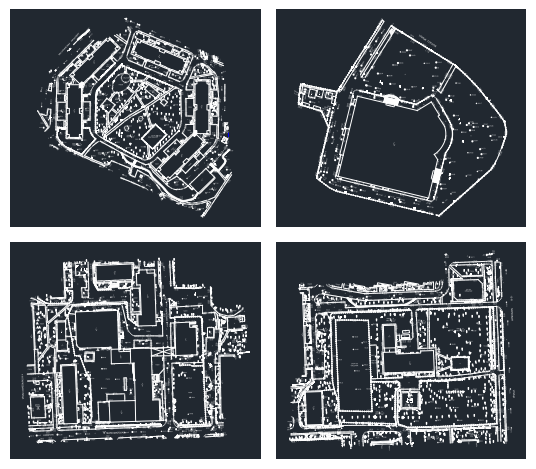

In [ ]:
# Taking only topography plans
path = './files/msk/output_msk'
all_dxf_files = [f for f in os.listdir(path) if f.lower().endswith('tp.dxf')]

# Just taking the first 4
selected_files = all_dxf_files[:4]

file_list = [
    os.path.join(path, selected_files[0]),
    os.path.join(path, selected_files[1]),
    os.path.join(path, selected_files[2]),
    os.path.join(path, selected_files[3]),
]

fig, axes = plt.subplots(2, 2, figsize=(5, 5))
axes_list = axes.flatten()
for ax, filename in zip(axes_list, file_list):
    draw_dxf_on_axes(filename, ax)

plt.tight_layout()
plt.show()

Notice, that they are fully size zoomed. Usually engineers work in approximately x5 zoom compared to the one shown above.  
Here is one of the plans in a slightly bigger scale. Single objects such as trees, playground, sidewalks are seen.  
This is a relatively small plan in terms of landscape design industry, most objects are (in average) 10 times bigger.

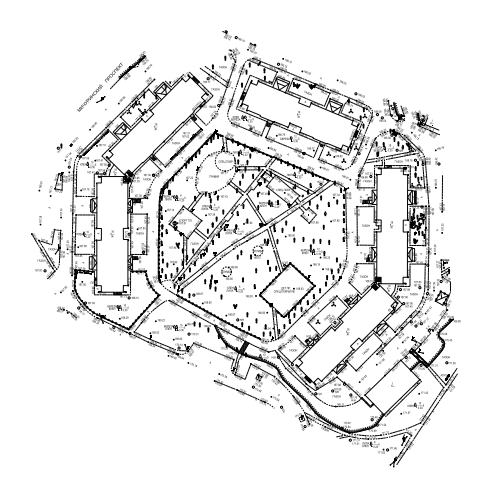

In [ ]:
doc = ezdxf.readfile(os.path.join(path, selected_files[0]))
msp = doc.modelspace()

fig = plt.figure(figsize=(10, 20))
ax = fig.add_axes([0, 0, 1, 1])

# Using white background for better visibility
cfg = config.Configuration(
    background_policy=config.BackgroundPolicy.WHITE,
    color_policy=config.ColorPolicy.BLACK
)

ctx = RenderContext(doc)
out = MatplotlibBackend(ax)
Frontend(ctx, out, config=cfg).draw_layout(msp, finalize=True)

plt.show()

Now let's look at some engineering utilities

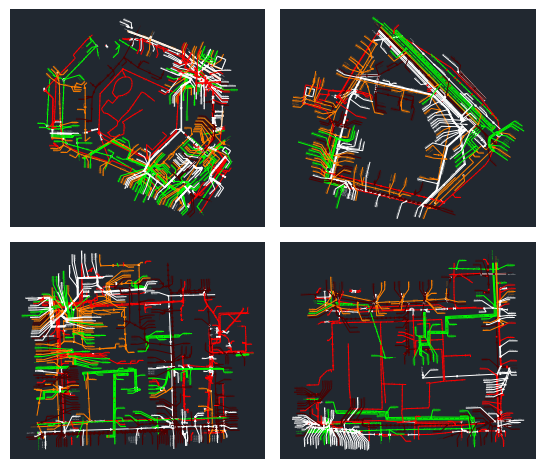

In [ ]:
# Taking only engineering utilities plans
path = './files/msk/output_msk'
all_dxf_files = [file for file in os.listdir(path) if file.endswith('up.dxf')]

# Taking the same 4 files
selected_files = all_dxf_files[:4]

file_list = [
    os.path.join(path, selected_files[0]),
    os.path.join(path, selected_files[1]),
    os.path.join(path, selected_files[2]),
    os.path.join(path, selected_files[3]),
]

fig, axes = plt.subplots(2, 2, figsize=(5, 5))
axes_list = axes.flatten()
for ax, filename in zip(axes_list, file_list):
    draw_dxf_on_axes(filename, ax)

plt.tight_layout()
plt.show()

### 2.1. Let's now count the areas of the dataset objects in square meters

Moscow dataset:

In [ ]:
folder_path = './files/msk/output_msk'
msk_files = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.lower().endswith('tp.dxf')]
results = []

# Parallel calculations
with ProcessPoolExecutor() as executor:
    futures = [executor.submit(calculate_dxf_area, path) for path in msk_files]
    for future in futures:
        results.append(future.result())
        
msk_df = pd.DataFrame(results, columns=['File', 'Area'])

In [ ]:
msk_df.describe()

,Area
count,69.000000
mean,218712.717142
std,769803.266218
min,45.658493
25%,9854.283495
50%,27374.696243
75%,88762.575767
max,4900112.981845


Regions dataset:

In [ ]:
folder_path = './files/regions/output_regions'
region_files = [os.path.join(folder_path, file) for file in os.listdir(folder_path)]
results = []

with ProcessPoolExecutor() as executor:
    futures = [executor.submit(calculate_dxf_area, path) for path in region_files]
    for future in futures:
        results.append(future.result())
        
regions_df = pd.DataFrame(results, columns=['File', 'Area'])

In [ ]:
regions_df.describe()

,Area
count,146.000000
mean,312158.928545
std,366736.759435
min,2792.367679
25%,45764.546752
50%,171235.364262
75%,421455.206366
max,1748345.284920


Total areas of two parts of the data and the summarized one: 

In [ ]:
msk_total_area = round(msk_df["Area"].sum())
print(f'Total Moscow area: {msk_total_area} sq meters')
regions_total_area = round(regions_df["Area"].sum())
print(f'Total regions area: {regions_total_area} sq meters')
print(f'Total area: {msk_total_area + regions_total_area} sq meters')

Total Moscow area: 15091177 sq meters
Total regions area: 45575204 sq meters
Total area: 60666381 sq meters


### 2.2. Visualization of areas distribution
We took 95% of the data to exclude outliers

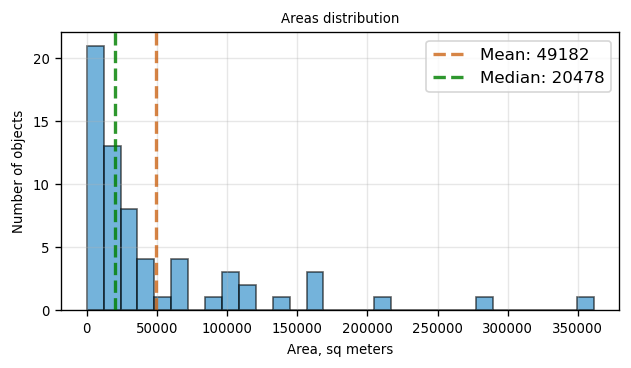

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.to_numeric(msk_df['Area'], errors='coerce').dropna()
data = data[data > 0]

upper = data.quantile(0.95)
data_trimmed = data[data <= upper]

plt.figure(figsize=(6, 3), dpi=120)

plt.hist(data_trimmed, bins=30, color="#1881C3", alpha=0.6, edgecolor='black')

mean_val = round(data_trimmed.mean())
median_val = round(data_trimmed.median())

plt.axvline(mean_val, color="#ca5e0cc3", linestyle='--', linewidth=2, label=f'Mean: {mean_val}')
plt.axvline(median_val, color="#008000D1", linestyle='--', linewidth=2, label=f'Median: {median_val}')

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.title('Areas distribution', fontsize=8)
plt.xlabel('Area, sq meters', fontsize=8)
plt.ylabel('Number of objects', fontsize=8)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
import os
import ezdxf
import numpy as np
import pandas as pd
import folium
from folium.plugins import MarkerCluster
from concurrent.futures import ThreadPoolExecutor
from pyproj import Transformer



def get_first_valid_point(filepath, zero_tol=1.0):
    """Return one representative non-zero (x, y) point from a DXF file."""
    try:
        doc = ezdxf.readfile(filepath)
        msp = doc.modelspace()

        for entity in msp:
            dxftype = entity.dxftype()
            candidates = []

            if dxftype == "LWPOLYLINE":
                candidates = [(float(x), float(y)) for x, y in entity.vertices()]
            elif dxftype == "POLYLINE":
                candidates = [(float(v[0]), float(v[1])) for v in entity.points()]
            elif dxftype == "LINE":
                candidates = [
                    (float(entity.dxf.start.x), float(entity.dxf.start.y)),
                    (float(entity.dxf.end.x), float(entity.dxf.end.y)),
                ]
            elif dxftype in ("TEXT", "MTEXT", "INSERT") and hasattr(entity.dxf, "insert"):
                candidates = [(float(entity.dxf.insert.x), float(entity.dxf.insert.y))]

            for x, y in candidates:
                if np.isfinite(x) and np.isfinite(y) and (abs(x) > zero_tol or abs(y) > zero_tol):
                    return filepath, x, y

        return filepath, None, None
    except Exception:
        return filepath, None, None


folder_path = './files/msk/output_msk'
msk_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith('tp.dxf')]

# Parallel extraction of one point per file
points = []
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(get_first_valid_point, path) for path in msk_files]
    for future in futures:
        points.append(future.result())

points_df = pd.DataFrame(points, columns=['File', 'X', 'Y']).dropna(subset=['X', 'Y']).reset_index(drop=True)

print(f"Total files: {len(msk_files)}")
print(f"Files with a valid point: {len(points_df)}")
print("\nSource coordinate ranges:")
print(points_df[['X', 'Y']].describe().loc[['min', '50%', 'max']])

In [ ]:
plot_df['name'] = plot_df['File'].map(os.path.basename)

fig = px.scatter_mapbox(
    plot_df,
    lat='lat',
    lon='lon',
    hover_name='name',
    zoom=9,
    center=dict(lat=plot_df['lat'].mean(), lon=plot_df['lon'].mean()),
    height=650,
    mapbox_style='carto-positron',
)
fig.update_traces(marker=dict(size=8, color='#1f77b4'))
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.show()

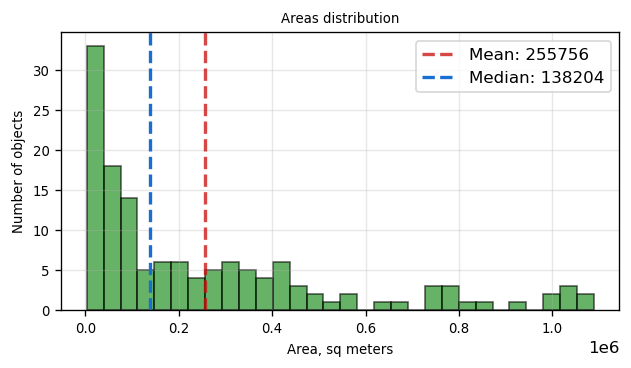

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.to_numeric(regions_df['Area'], errors='coerce').dropna()
data = data[data > 0]

upper = data.quantile(0.95)
data_trimmed = data[data <= upper]

plt.figure(figsize=(6, 3), dpi=120)

plt.hist(data_trimmed, bins=30, color="#008000D1", alpha=0.6, edgecolor='black')

mean_val = round(data_trimmed.mean())
median_val = round(data_trimmed.median())

plt.axvline(mean_val, color="#ca0f0cc3", linestyle='--', linewidth=2, label=f'Mean: {mean_val}')
plt.axvline(median_val, color="#196FD1FF", linestyle='--', linewidth=2, label=f'Median: {median_val}')

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.title('Areas distribution', fontsize=8)
plt.xlabel('Area, sq meters', fontsize=8)
plt.ylabel('Number of objects', fontsize=8)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#

In [23]:
import pyproj
import numpy as np

# МСК Moscow city (local origin)
msk_moscow_proj = (
    "+proj=tmerc +lat_0=55.66666666666667 +lon_0=37.5 +k=1 "
    "+x_0=0 +y_0=0 +ellps=krass +units=m +no_defs "
    "+towgs84=23.57,-140.95,-79.8,0,0.35,0.79,-0.22"
)

# МСК-50 (Moscow Oblast), 4 zones encoded in the first digit of X
def msk50_proj(zone):
    cm_lon = 35.48333333 + 3 * (zone - 1)   # 35.48, 38.48, 41.48, 44.48
    fe = zone * 1_000_000 + 300_000          # 1.3M, 2.3M, 3.3M, 4.3M
    return (
        f"+proj=tmerc +lat_0=0 +lon_0={cm_lon} +k=1 "
        f"+x_0={fe} +y_0=-5720239.62 +ellps=krass +units=m +no_defs "
        f"+towgs84=23.57,-140.95,-79.8,0,0.35,0.79,-0.22"
    )

transformers = {
    'msk-moscow': pyproj.Transformer.from_crs(msk_moscow_proj, 4326, always_xy=True),
    **{f'msk-50-z{z}': pyproj.Transformer.from_crs(msk50_proj(z), 4326, always_xy=True)
       for z in range(1, 5)},
}

def detect_and_convert(x, y):
    """Pick a CRS by X magnitude, convert to (lat, lon, crs_name)."""
    if not (np.isfinite(x) and np.isfinite(y)):
        return None, None, None
    ax = abs(x)
    if ax < 100_000:
        name = 'msk-moscow'
    elif 1_000_000 <= ax < 5_000_000:
        name = f'msk-50-z{int(ax // 1_000_000)}'
    else:
        return None, None, None
    lon, lat = transformers[name].transform(float(x), float(y))
    if not (41 <= lat <= 82 and 19 <= lon <= 180):  # sanity: inside Russia
        return None, None, None
    return lat, lon, name

raw_df[['lat', 'lon', 'crs_guess']] = raw_df.apply(
    lambda r: pd.Series(detect_and_convert(r['X'], r['Y'])),
    axis=1
)

print("CRS guesses:")
print(raw_df['crs_guess'].value_counts(dropna=False))
print(f"\nGeocoded: {raw_df['lat'].notna().sum()} / {len(raw_df)}")

plot_df = raw_df.dropna(subset=['lat', 'lon']).copy()
print(f"Lat range: {plot_df['lat'].min():.3f} – {plot_df['lat'].max():.3f}")
print(f"Lon range: {plot_df['lon'].min():.3f} – {plot_df['lon'].max():.3f}")

CRS guesses:
msk-50-z2     119
msk-50-z1      20
msk-moscow      7
Name: crs_guess, dtype: int64

Geocoded: 146 / 146
Lat range: 54.535 – 57.806
Lon range: 34.835 – 38.112


In [ ]:
fig = px.scatter_mapbox(
    plot_df,
    lat='lat',
    lon='lon',
    color='crs_guess',
    hover_name='name',
    zoom=6,
    center=dict(lat=plot_df['lat'].mean(), lon=plot_df['lon'].mean()),
    height=700,
    mapbox_style='carto-positron',
)
fig.update_traces(marker=dict(size=8))
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.show()

### 3. Collecting the data.
Now we will collect all the objects in the datasets and store them in a DataFrame. We will also check some additional information about the number of layers, single objects, their types.  
Again, we will do this separately for Moscow and Regions due to the structure difference.  

### 3.1. Moscow dataset parsing

In [2]:
from eda import parse_dxf_to_table, analyze_dataset

folder_path = './files/msk/output_msk'
msk_files = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.lower().endswith('.dxf')]

results = []

# Parallel calculations
with ProcessPoolExecutor() as executor:
    futures = [executor.submit(parse_dxf_to_table, path) for path in msk_files]
    for future in futures:
        df = future.result()
        if df is not None:
            results.append(df)

if results:
    msk_df = pd.concat(results, ignore_index=True)
    msk_df.to_csv('msk_geo_dataset_v2.csv', index=False)
    print("Dataset successfully saved to 'msk_geo_dataset_v2.csv'")

    # And now analyze combined dataset
    analyze_dataset(msk_df)
else:
    print("No valid data was extracted from the provided DXF files.")

Dataset successfully saved to 'msk_geo_dataset_v2.csv'
Total amount of objects: 3903465
LINE          1166119
LWPOLYLINE     931998
ARC            745312
ELLIPSE        602270
INSERT         199176
TEXT           180692
CIRCLE          55951
HATCH           11266
REGION          10293
MTEXT             261
POINT             127
Отдельно стоящее дерево                 2176008
Граница растительности и грунта          600550
Горизонтали                              198174
Граница улицы                            192941
Леса и газоны                            147138
Откосы                                   141035
Полоса деревьев                          102735
0                                         55628
Ограды                                    27469
Кабель электрический                      26384
Колодцы                                   20197
Водопровод                                15090
Водосток                                  13106
Здания                                    1266

In [3]:
msk_df.describe()

,Source_File,Handle,Layer,Type,BlockName,Text,l1,l2
count,3903465,3903465,3903465,3903465,199176,180953,0,0
unique,501,3535756,98,11,22300,11383,0,0
top,x_los_part_2_tp.dxf,7C,Отдельно стоящее дерево,LINE,m_283_1,А,NaN,NaN
freq,1342384,361,2176008,1166119,160,6031,NaN,NaN


In [4]:
msk_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3903465 entries, 0 to 3903464
Data columns (total 8 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   Source_File  string
 1   Handle       string
 2   Layer        string
 3   Type         string
 4   BlockName    string
 5   Text         string
 6   l1           object
 7   l2           object
dtypes: object(2), string(6)
memory usage: 238.2+ MB


### 3.2. Regions dataset parsing.

In [3]:
# # Do all the same for Regions dataset
# from eda import parse_dxf_to_table, analyze_dataset

# folder_path = './files/regions/output_regions'
# regions_files = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.lower().endswith('.dxf')]

# results = []

# with ProcessPoolExecutor() as executor:
#     futures = [executor.submit(parse_dxf_to_table, path) for path in regions_files]
#     for future in futures:
#         df = future.result()
#         results.append(df)

# regions_df = pd.concat(results, ignore_index=True)
# regions_df.to_csv('regions_geo_dataset.csv', index=False)

# analyze_dataset(regions_df)
from eda import parse_dxf_to_table, analyze_dataset
regions_df = pd.read_csv('labeled_regions_df.csv', low_memory=False)
analyze_dataset(regions_df)

Total amount of objects: 3069680
INSERT               820968
TEXT                 646164
POINT                436410
LWPOLYLINE           426049
LINE                 414358
HATCH                 90552
ARC                   63631
MTEXT                 58547
CIRCLE                49501
POLYLINE              26333
ATTDEF                14646
REGION                 7536
3DFACE                 5227
SPLINE                 3005
MULTILEADER            2689
ACAD_PROXY_ENTITY      2277
WIPEOUT                1585
IMAGE                    94
ELLIPSE                  55
MLINE                    30
SOLID                    11
DIMENSION                 6
LEADER                    5
VIEWPORT                  1
0                                                                                                                             489216
Растительность                                                                                                                222382
Survey.td2                   

In [6]:
regions_df.describe()

,Source_File,Handle,Layer,Type,BlockName,Text,l1,l2
count,3069680,3069680,3069680,3069680,820968,700276,0,0
unique,146,1680122,1331,24,3949,115218,0,0
top,12-01-2023-ИГДИ Г.3_с газом.dxf,11F,0,INSERT,1_401,А,NaN,NaN
freq,201274,32,489216,820968,115441,7692,NaN,NaN


In [7]:
regions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069680 entries, 0 to 3069679
Data columns (total 8 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   Source_File  object
 1   Handle       object
 2   Layer        object
 3   Type         object
 4   BlockName    object
 5   Text         object
 6   l1           object
 7   l2           object
dtypes: object(8)
memory usage: 187.4+ MB


### 4. Dataset labeling

To label our dataframe we can use common patterns for some objects, which are frequently repeated in our files, such as:
- elevation numbers (like *"163.12"*);
- trees;  
- buildings;  
- curbs;  
- etc.  
  
These objects will be labeled automatically using dictionaries and regular expressions. All other objects will be labeled manually.

    The labeling pipeline is the following:

    1. Text dictionary mapping 
    2. Elevation text RegExp labeling  
    3. Layers dictionary mapping  
    4. Manual labeling



### 4.1. Target classes structure.
We need to provide a unified taget classes structure (ground truth) for our future model. The main challenge here is to develop a structure that will cover all the objects, i.e. each object of the geodata will have its own informative label. We will also store "unknown" class for objects with unidetified information. The example of such infomation can be lines / dots on the "0" layer. "0" layer is a default layer which is commonly used on an empty files in CAD programms. Bad practice to use this layer for working files, since it doesn't store any information. Therefore, such an objects will be labeled as "unknown" (unless this is a Text / MText type object) and processed later.  

We use two DataFrames due to the location difference, but the ground truth classes structure will remain the same for both of them. However, we will need to train two different models to predict these classes for two different types of raw data. During the first iteration the strategy of Transfer learning approach was chosen: we are going to train Moscow model, and then provide fine-tuning for Regions.

In [ ]:
target_classes = {
    "Здания и сооружения": [
        "Подпорная стенка",
    ],
    "Водные объекты": [],
    "Твёрдые покрытия": [
        "Асфальт",
        "Бетон",
        "Архитектурный бетон",
        "Плитка",
        "Брусчатка",
        "Гранит",
        "Камень",
        "Деревянный настил",
        "Металлический настил",
    ],
    "Водопроницаемые покрытия": [
        "Грунт",
        "Песок",
        "Щебень",
        "Гравий",
        "Газонная решётка",
        "Деревянная щепа",
        "Мульча",
        "Резиновая крошка",
    ],
    "Покрытия эксплуатируемой кровли": [
    ],
    "Элементы благоустройства": [
        "Ступени",
        "Пандус"
    ],
    "УДС": [
        "Бортовой камень",
        "Дорожная разметка",
        "Трамвайная пути",
        "ЖД пути"
    ],
    "Озеленение": [
        "Газон",
        "Цветники",
        "Деревья",
        "Кустарники",
        "Откос",
    ],
    "Инженерные сети": [
        "Водопровод",
        "Газопровод",
        "Канализация бытовая",
        "Ливневая канализация",
        "Теплосеть",
        "Электроснабжение",
        "Наружное освещение",
        "Сети связи",
        "Прочие кабели",
        "Прочие трубопроводы",
        "Дренаж",
        "Инженерная инфраструктура"
    ],
    "МАФ": [
        "Уличная мебель",
        "Ограждение",
        "Детское оборудование",
        "Спортивное оборудование",
        "Урна / Контейнер",
        "Информационная конструкция",
        "Памятники",
    ],
    "Рельеф": [
        "Отметки высот",
        "Горизонтали",
    ],
    "Служебные элементы": [
        "Граница проектирования",
        "Красная линия",
        "Ось",
        "Размерная линия",
        "Условные обозначения",
        "Штамп",
    ],
    "Неизвестно": [],
}

In [ ]:
# regions_df = pd.read_csv('regions_geo_dataset.csv')
# msk_df = pd.read_csv('msk_geo_dataset.csv')

C:\Users\artem\AppData\Local\Temp\ipykernel_16604\3252270049.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  msk_df = pd.read_csv('msk_geo_dataset.csv')


### 4.2. Moscow geodata labeling

### Maping rules
First we apply two mapping dictionaries: 
- for frequently used unique texts
- for unique layers

That will be effectively by the same reason - the Moscow geodata consists of a structured data, and its classes are set by the government regulators (Moscow City Geological Trust - "МГГТ"):

In [61]:
# Dictionary for labeling objects of type "TEXT" / "MTEXT"
rules_mapping = {
    "Озеленение": {
        "Газон": [
            "Отдельно стоящее дерево", "Леса и газоны", "Полоса деревьев",
            "Озеленение"
        ],
        "Грунт": [
            "ГРУНТ", "ГР"
        ],
        "Деревья": [
            "БЕРЕЗА", "ЛИПА", "ОСИНА", "ЛИСТВЕННИЦА", 
            "ОЛЬХА", "СОСНА", "ГАЗОН", "ДЕК", "ТРАВА", "КАНАВА", "ДЕРЕВО", "КЛЕН"
        ]
    },
    
    "Здания и сооружения": {
        None: [ 
            "Здания", "Крыльца", "Части зданий", "Дом", "Павильон", 
            "Номер дома", "СМ", "ПЛ", "К", "КН", "Д", "КД", "КЖ", "КМ", 
            "М", "ДОМ", "ПАВИЛЬОН", "КОРП"
        ]
    },
    
    "Твердые покрытия": {
        "Асфальт": [
            "УЛИЦА", "ПРОЕЗД", "ПР.", "УЛ.", "ПЕР.", "Ш.", "ШОССЕ", "А", "АСФ"
        ],
        "Плитка": [
            "Ц", "БР", "БРУСЧ"
        ],
        "Бетон": [
            "БЕТ", "ФУНД"
        ],
        "Резиновая крошка": [
            "СПЕЦ.ПОКР", "ДЕТ", "СПОРТ", "ДЕТ.ПЛ"
        ]
    },
    
    "Водопроницаемые покрытия": {
        "Щебень": [
            "Щ"
        ],
        "Гравий": [
            "ГРАВИЙ"
        ],
        "Песок": [
            "ПЕСОК", "ПЕС", "ПЕСЧ"
        ],
        "Деревянный настил": [
            "ДЕР.НАСТИЛ", "ДЕР", "НАСТИЛ", "Д.НАСТИЛ"
        ],
        "Металлический настил": [
            "М.НАСТИЛ", "МЕТ.НАСТИЛ", "МЕТАЛЛ.НАСТИЛ", "МЕТАЛЛИЧ.НАСТИЛ"
        ]
    },
    
    "Водные объекты": {
        None: [
            "РЕКА", "РЕК", "Р", "ОЗ.", "ОЗЕРО", "ПРУД"
        ]
    }
}


# Dictionary for layers names
layer_labels = {
    "Красные линии": ("Служебные элементы", "Красная линия"),
    "Горизонтали": ("Рельеф", "Горизонтали"),
    "Части зданий": ("Здания и сооружения", None),
    "Отдельно стоящее дерево": ("Озеленение", "Дерево"),
    "Граница улицы": ("Элементы благоустройства", "Бортовой камень"),
    "Крыльца": ("Здания и сооружения", None),
    "Внутреннее заполнение": ("Здания и сооружения", None),
    "Колодцы": ("Инженерные сети", "Инженерная инфраструктура"),
    "Полоса деревьев": ("Озеленение", "Газон"),
    "Светофоры": ("Инженерные сети", "Инженерная инфраструктура"),
    "Леса и газоны": ("Озеленение", "Газон"),
    "Номер дома": ("Здания и сооружения", None),
    "Откосы": ("Озеленение", "Газон"),
    "Вентиляторы": ("Инженерные сети", "Инженерная инфраструктура"),
    "Фонари": ("Инженерные сети", "Наружное освещение"),
    "Здания": ("Здания и сооружения", None),
    "Геодезические пункты": ("Инженерные сети", "Инженерная инфраструктура"),
    "Граница растительности и грунта": ("Озеленение", "Газон"),
    "Ограды": ("МАФ", "Ограждение"),
    "Граница площадки": ("Элементы благоустройства", "Бортовой камень"),
    "Лестницы набережных": ("Здания и сооружения", "Лестницы"),
    "Пояснительные подписи": ("Служебные элементы", "Условные обозначения"),
    "Парапеты": ("Здания и сооружения", "Подпорная стенка"),
    "Вышки": ("Инженерные сети", "Инженерная инфраструктура"),
    "Фонтаны": ("Инженерные сети", "Инженерная инфраструктура"),
    "Навесы": ("Здания и сооружения", None),
    "Выгребные ямы": ("Здания и сооружения", None),
    "Памятники": ("МАФ", "Памятники"),
    "Топографические объекты": ("Инженерные сети", "Инженерная инфраструктура"),
    "дорисовки": ("Неизвестно", None),
    "Крышки колодцев": ("Инженерные сети", "Инженерная инфраструктура"),
    "Растительность": ("Озеленение", "Газон"),
    "Кабель Мосэнерго": ("Инженерные сети", "Электроснабжение"),
    "Кабель связи": ("Инженерные сети", "Сети связи"),
    "Водосток": ("Инженерные сети", "Ливневая канализация"),
    "Канализация самотёчная": ("Инженерные сети", "Канализация бытовая"),
    "Водопровод": ("Инженерные сети", "Водопровод"),
    "Кабели": ("Инженерные сети", "Прочие кабели"),
    "Кабель защиты": ("Инженерные сети", "Прочие кабели"),
    "Дренаж": ("Инженерные сети", "Прочие кабели"),
    "Теплосеть": ("Инженерные сети", "Теплосеть"),
    "Подземные коммуникации": ("Инженерные сети", "Инженерная инфраструктура"),
    "Канализация напорная": ("Инженерные сети", "Канализация бытовая"),
    "Газопровод": ("Инженерные сети", "Газопровод"),
    "0": ("Неизвестно", None),
    "Кабель Мосэнерго проектный": ("Инженерные сети", "Электроснабжение"),
    "Кабели проектные": ("Инженерные сети", "Прочие кабели"),
    "Люки": ("Инженерные сети", "Инженерная инфраструктура"),
    "Береговая линия": ("Неизвестно", None),
    "Общий коллектор": ("Инженерные сети", "Инженерная инфраструктура"),
    "Кабель защиты проектный": ("Инженерные сети", "Прочие кабели"),
    "Газопровод проектный": ("Инженерные сети", "Газопровод"),
    "Теплосеть проектная": ("Инженерные сети", "Теплосеть"),
    "Столбы": ("Инженерные сети", "Инженерная инфраструктура"),
    "Опоры контакной сети": ("Инженерные сети", "Инженерная инфраструктура"),
    "Указатель подз коммуникаций": ("Инженерные сети", "Инженерная инфраструктура"),
    "Трубы": ("Инженерные сети", "Прочие кабели"),
    "Павильоны": ("Здания и сооружения", None),
    "Бортовой камень": ("Элементы благоустройства", "Бортовой камень"),
    "ЛЭП": ("Инженерные сети", "Инженерная инфраструктура"),
    "Кабель электрический": ("Инженерные сети", "Электроснабжение"),
    "Промводопровод": ("Инженерные сети", "Водопровод"),
    "Подземные коммуникации проектные": ("Инженерные сети", "Инженерная инфраструктура"),
    "Кабель электрический проектный": ("Инженерные сети", "Электроснабжение"),
    "Кабель связи проектный": ("Инженерные сети", "Сети связи"),
    "Мосты": ("Здания и сооружения", None),
    "Трамвайные линии": ("Элементы благоустройства", "Трамвайные пути"),
    "Водопровод проектный": ("Инженерные сети", "Водопровод"),
    "Трубопроводы": ("Инженерные сети", "Прочие трубопроводы"),
    "Рамки": ("Служебные элементы", "Штамп"),
    "Координатные кресты": ("Служебные элементы", "Условные обозначения"),
    "Граница заказа": ("Служебные элементы", "Условные обозначения"),
    "Подписи рамок": ("Служебные элементы", "Условные обозначения"),
    "Водосток проектный": ("Инженерные сети", "Ливневая канализация"),
    "Подземный переход": ("Здания и сооружения", None),
    "Трубы под дорогами": ("Инженерные сети", "Прочие трубопроводы"),
    "Теплицы": ("Здания и сооружения", None),
    "Спец сооружения": ("Здания и сооружения", None),
    "Железные дороги": ("Элементы благоустройства", "ЖД пути"),
    "Канализация напорная проектная": ("Инженерные сети", "Канализация бытовая"),
    "Болота": ("Водные объекты", None),
    "Грунты": ("Озеленение", "Грунт"),
    "Канализация самотёчная проектная": ("Инженерные сети", "Канализация бытовая"),
    "граница площадки": ("Элементы благоустройства", "Бортовой камень"),
    "Платформы ЖД": ("Здания и сооружения", None),
    "Просеки в лесу": ("Озеленение", "Грунт"),
    "Громоотвод": ("Инженерные сети", "Инженерная инфраструктура"),
    "Трубопроводы проектные": ("Инженерные сети", "Прочие трубопроводы"),
    "Дренаж проектный": ("Инженерные сети", "Дренаж"),
    "Будка телефонная": ("Здания и сооружения", None),
    "Внутреннее заполнение (Construction)": ("Здания и сооружения", None),
    "Крыльца (Construction)": ("Здания и сооружения", None),
    "Граница площадки (Construction)": ("Элементы благоустройства", "Бортовой камень"),
    "Подъемные краны": ("Неизвестно", None),
    "Леса и газоны (Construction)": ("Озеленение", "Газон"),
    "Граница улицы (Construction)": ("Элементы благоустройства", "Бортовой камень"),
    "Отметка высоты пола": ("Рельеф", "Отметки высот"),
    "Территории": ("Элементы благоустройства", "Бортовой камень")
}

### 4.2.1. Applying text dictionary mapping:

In [62]:

text_labels = {}
for l1, l2_dict in rules_mapping.items():
    for l2, keywords in l2_dict.items():
        for kw in keywords:
            text_labels[kw.strip().upper()] = (l1, l2)

def classify(text):
    t = str(text).strip().upper()
    if t in text_labels:
        return text_labels[t]
    return (None, None)


labeled_msk_df = msk_df[msk_df['Type'].str.upper().isin(['TEXT', 'MTEXT'])].copy()
labeled_msk_df[['l1', 'l2']] = labeled_msk_df['Text'].apply(lambda x: pd.Series(classify(x)))

### 4.2.2. Elevation text RexExp mapping
Since the amount of texts containing elevation data is a significant percentage in the dataset - we will apply regular expression to label them correctly:

In [63]:
# Defining the pattern for coordininates like "12345"
coordinates = r'^\s*-?\d+\s*$'
# And the pattern for elevation points like "164.20"
elevations = r'^\s*-?\d+[\.,][\d\.,\s]*$'

# Create masks
mask_coordinate = labeled_msk_df['Text'].str.match(elevations)
mask_elevation = labeled_msk_df['Text'].str.match(coordinates)

labeled_msk_df.loc[mask_elevation, ['l1', 'l2']] = ['Горизонтали', 'Отметки высот']
labeled_msk_df.loc[mask_coordinate, ['l1', 'l2']] = ['Служебные элементы', 'Координаты']

### 4.2.3. Layers dictionary mapping:

In [64]:
for Layer, (l1, l2) in layer_labels.items():
    mask = labeled_msk_df['l1'].isna() & (labeled_msk_df['Layer'] == Layer)
    labeled_msk_df.loc[mask, ['l1', 'l2']] = [l1, l2]

### 4.2.4. Results
The final amount of nan values of l1-class layers is zero, and the amount of nanvalues of l2-class layers is 22_551. This is quite good result, since the objects like buildings, rivers / lakes, or "0" layer.  
Therefore, there is no need for manual labeling of Moscow geodata.

In [66]:
print(f'None values of l1: {labeled_msk_df["l1"].isna().sum()}')
print(f'None values of l2: {labeled_msk_df["l2"].isna().sum()}')

None values of l1: 0
None values of l2: 22551


In [74]:
labeled_msk_df[labeled_msk_df['l2'].isna()]['l1'].unique()

array(['Здания и сооружения', 'Неизвестно', 'Водные объекты'],
      dtype=object)

### 4.3. Regions geodata labeling

Since the Regions data is very instructured we will apply a slightly different approach for it. Instead of mapping using strict layers / texts names we will use ReGexp rules. 

In [81]:
print(f'Total amount of objects: {len(regions_df)}')
print(f'Unique Layers: {regions_df["Layer"].nunique()}')
print(f'Unique Texts: {regions_df["Text"].nunique()}')

Total amount of objects: 3069680
Unique Layers: 1331
Unique Texts: 115218


In [76]:
# Text mapping
labeled_regions_df = regions_df[regions_df['Type'].str.upper().isin(['TEXT', 'MTEXT'])].copy()
labeled_regions_df[['l1', 'l2']] = labeled_regions_df['Text'].apply(lambda x: pd.Series(classify(x)))


coordinates = r'^\s*-?\d+\s*$'
elevations = r'^\s*-?\d+[\.,][\d\.,\s]*$'
mask_coordinate = labeled_regions_df['Text'].str.match(elevations, na=False)
mask_elevation = labeled_regions_df['Text'].str.match(coordinates, na=False)
labeled_regions_df.loc[mask_elevation, ['l1', 'l2']] = ['Горизонтали', 'Отметки высот']
labeled_regions_df.loc[mask_coordinate, ['l1', 'l2']] = ['Служебные элементы', 'Координаты']

for Layer, (l1, l2) in layer_labels.items():
    mask = labeled_regions_df['l1'].isna() & (labeled_regions_df['Layer'] == Layer)
    labeled_regions_df.loc[mask, ['l1', 'l2']] = [l1, l2]


In [78]:
print(f'None values of l1: {labeled_regions_df["l1"].isna().sum()}')
print(f'None values of l2: {labeled_regions_df["l2"].isna().sum()}')

None values of l1: 141109
None values of l2: 145053


In [95]:
labeled_regions_df[labeled_regions_df['l1'].isna()]['Text'].unique()

array(['Сплошные горизонтали проведены через 0.5м.',
       'Система высот Балтийская.', 'Система координат МСК-50.', ...,
       'лесопосадки молодые', 'заросли камыша', 'проволока'], dtype=object)

In [97]:
print(f'Unique Layers: {labeled_regions_df["l1"].unique()}')
print(f'Unique Texts: {labeled_regions_df["l2"].unique()}')

Unique Layers: ['Горизонтали' None 'Здания и сооружения' 'Неизвестно' 'Твердые покрытия'
 'Служебные элементы' 'Озеленение' 'Водные объекты'
 'Водопроницаемые покрытия' 'Инженерные сети' 'Рельеф']
Unique Texts: ['Отметки высот' None 'Асфальт' 'Координаты' 'Плитка' 'Грунт' 'Деревья'
 'Щебень' 'Водопровод' 'Прочие кабели' 'Инженерная инфраструктура' 'Бетон'
 'Песок' 'Газопровод' 'Гравий' 'Сети связи' 'Горизонтали'
 'Деревянный настил' 'Газон' 'Теплосеть']


In [109]:
import pandas as pd

# Автоматически определяем короткие ключи (<=2 символа) для строгого совпадения
strict_labels = set()
for l1, l2_dict in rules_mapping.items():
    for l2, keywords in l2_dict.items():
        for kw in keywords:
            if len(kw.strip()) <= 2:
                strict_labels.add(kw.strip().upper())

print("Строгие метки:", strict_labels)

def classify_text(text):
    if pd.isna(text): return None, None
    t = str(text).strip().upper()
    for l1, l2_dict in rules_mapping.items():
        for l2, keywords in l2_dict.items():
            for kw in keywords:
                kw_u = kw.strip().upper()
                if kw_u in strict_labels:
                    if t == kw_u: return l1, l2
                else:
                    if kw_u in t: return l1, l2
    return None, None

def classify_layer(layer):
    if pd.isna(layer): return None, None
    layer_str = str(layer).strip()
    # Точное совпадение
    if layer_str in layer_labels:
        return layer_labels[layer_str]
    # Без учёта регистра
    for key, label in layer_labels.items():
        if key.lower() == layer_str.lower():
            return label
    # Подстрока (только для ключей длиннее 2 символов)
    for key, label in layer_labels.items():
        if len(key) > 2 and key.lower() in layer_str.lower():
            return label
    return None, None

labeled_regions_df = regions_df.copy()

mask_text = labeled_regions_df['Type'].str.upper().isin(['TEXT', 'MTEXT'])

results = labeled_regions_df.apply(
    lambda row: classify_text(row['Text']) if mask_text[row.name] else classify_layer(row['Layer']),
    axis=1
)

labeled_regions_df[['l1', 'l2']] = pd.DataFrame(results.tolist(), index=labeled_regions_df.index)

mapped = labeled_regions_df['l1'].notna().sum()
print(f"Размечено: {mapped:,} ({mapped/len(labeled_regions_df)*100:.1f}%)")
print(labeled_regions_df['l1'].value_counts(dropna=False))

Строгие метки: {'КЖ', 'КМ', 'Ш.', 'БР', 'ПЛ', 'ГР', 'КН', 'К', 'КД', 'СМ', 'М', 'А', 'Р', 'Ц', 'Щ', 'Д'}
Размечено: 951,622 (31.0%)
None                        2118058
Неизвестно                   485722
Озеленение                   367056
Рельеф                        41154
Инженерные сети               31121
Твердые покрытия              13922
Здания и сооружения           11179
Водопроницаемые покрытия        919
Водные объекты                  256
Элементы благоустройства        164
МАФ                             128
Служебные элементы                1
Name: l1, dtype: int64


In [137]:
labeled_regions_df[(labeled_regions_df['Layer']=='USLZNЛЮКИ') & (labeled_regions_df['l1'].notnull())]

,Source_File,Layer,Type,Text,l1,l2
359853,11-06-2022-ИГДИ-Г.3.dxf,USLZNЛЮКИ,INSERT,NaN,Инженерные сети,Инженерная инфраструктура
599233,12-04-2022-ИГДИ-1-Г.3 (1).dxf,USLZNЛЮКИ,INSERT,NaN,Инженерные сети,Инженерная инфраструктура
599234,12-04-2022-ИГДИ-1-Г.3 (1).dxf,USLZNЛЮКИ,INSERT,NaN,Инженерные сети,Инженерная инфраструктура
599235,12-04-2022-ИГДИ-1-Г.3 (1).dxf,USLZNЛЮКИ,INSERT,NaN,Инженерные сети,Инженерная инфраструктура
599236,12-04-2022-ИГДИ-1-Г.3 (1).dxf,USLZNЛЮКИ,INSERT,NaN,Инженерные сети,Инженерная инфраструктура
599237,12-04-2022-ИГДИ-1-Г.3 (1).dxf,USLZNЛЮКИ,INSERT,NaN,Инженерные сети,Инженерная инфраструктура
599238,12-04-2022-ИГДИ-1-Г.3 (1).dxf,USLZNЛЮКИ,INSERT,NaN,Инженерные сети,Инженерная инфраструктура
599239,12-04-2022-ИГДИ-1-Г.3 (1).dxf,USLZNЛЮКИ,INSERT,NaN,Инженерные сети,Инженерная инфраструктура
602822,12-04-2022-ИГДИ-1-Г.3 (1).dxf,USLZNЛЮКИ,INSERT,NaN,Инженерные сети,Инженерная инфраструктура
602823,12-04-2022-ИГДИ-1-Г.3 (1).dxf,USLZNЛЮКИ,INSERT,NaN,Инженерные сети,Инженерная инфраструктура


In [160]:

load_dotenv(dotenv_path='../../.env')
openai_key = os.getenv('OPENAI_KEY')

client = OpenAI(api_key=openai_key)

ONTOLOGY = """
You are labeling objects from topographic CAD drawings of Moscow.
You will receive a numbered list of layer names or text annotations.

Available classes (l1 → l2):
- Озеленение → Газон / Дерево / Кустарник / Грунт
- Здания и сооружения → null / Подпорная стенка / Лестницы
- Твердые покрытия → Асфальт / Плитка / Бетон / Брусчатка / Гранит / Деревянный настил / Металлический настил
- Водопроницаемые покрытия → Грунт / Песок / Щебень / Гравий / Газонная решётка / Деревянная щепа / Мульча / Резиновая крошка
- Элементы благоустройства → Бортовой камень / Ступени / Пандус / Дорожная разметка / Трамвайные пути / ЖД пути
- Инженерные сети → Водопровод / Газопровод / Канализация бытовая / Ливневая канализация / Теплосеть / Электроснабжение / Наружное освещение / Сети связи / Инженерная инфраструктура / Дренаж / Прочие кабели / Прочие трубопроводы
- МАФ → Ограждение / Уличная мебель / Детское оборудование / Спортивное оборудование / Урна / Памятники
- Рельеф → Отметки высот / Горизонтали / Откос
- Служебные элементы → Красная линия / Граница проектирования / Ось / Штамп / Условные обозначения
- Водные объекты → null
- Неизвестно → null

Context:
- Moscow topographic survey, MGTT standard
- "А", "АСФ" = asphalt, "КЖ"/"КМ" = building, "ДЕР" = tree
- Numbers (1, 2, 100, 1022, etc.) = Служебные элементы / Условные обозначения
- Each value is independent, do not relate them to each other

Respond STRICTLY as a JSON list, one object per id:
[{"id": 1, "l1": "класс", "l2": "подкласс или null"}]
No text other than JSON.
"""


def formatting(x):
    return str(x).strip().lower()


def parse_json(content: str) -> list:
    content = content.strip()
    if "```" in content:
        content = content.split("```")[1]
        if content.startswith("json"):
            content = content[4:]
    return json.loads(content.strip())


def process_batch(items: list[str]) -> dict:
    numbered = json.dumps(
        [{"id": i+1, "value": v} for i, v in enumerate(items)],
        ensure_ascii=False
    )

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": ONTOLOGY},
            {"role": "user",   "content": numbered}
        ]
    )

    parsed = parse_json(response.choices[0].message.content)

    result = {}
    for item in parsed:
        value = items[item['id'] - 1]
        l1 = item['l1']
        l2 = None if item['l2'] in (None, "null") else item['l2']
        result[formatting(value)] = (l1, l2)
    return result


def main(values: list[str], batch_size=100, max_workers=10) -> dict:
    batches = [values[i:i+batch_size] for i in range(0, len(values), batch_size)]
    results = {}

    print(f"Batches: {len(batches)}, in parallel: {max_workers}")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(process_batch, b): b for b in batches}
        for i, future in enumerate(as_completed(futures)):
            try:
                results.update(future.result())
                print(f"  {i+1}/{len(batches)} done ({len(results)})", end='\r')
            except Exception as e:
                print(f"\n  Batch error: {e}")

    print(f"\nFinished: {len(results)} values")
    return results

# Start labeling
labeled_regions_df = regions_df.copy()
labeled_regions_df['l1'] = None
labeled_regions_df['l2'] = None
texts_to_parse  = labeled_regions_df['Text'].dropna().astype(str).str.strip().unique().tolist()
layers_to_parse = labeled_regions_df['Layer'].dropna().astype(str).str.strip().unique().tolist()

print(f"Unique texts:  {len(texts_to_parse)}")
print(f"Unique layers:    {len(layers_to_parse)}")

# Save data
cache_path  = Path("llm_cache.pkl")
if cache_path.exists():
    with open(cache_path , "rb") as f:
        cache = pickle.load(f)
    text_llm  = cache["text"]
    layer_llm = cache["layer"]
else:
    text_llm = main(texts_to_parse)
    layer_llm = main(layers_to_parse)
    with open(cache_path , "wb") as f:
        pickle.dump({"text": text_llm, "layer": layer_llm}, f)


def get_label(row):
    if pd.notnull(row['l1']):
        return row['l1'], row['l2'] 
    text_result = text_llm.get(formatting(row['Text']))
    if text_result and text_result[0] not in (None, "Неизвестно"):
        return text_result

    return layer_llm.get(formatting(row['Layer']), (None, None))


mask = labeled_regions_df['l1'].isna()
if mask.any():
    new_labels = labeled_regions_df[mask].apply(get_label, axis=1).tolist()
    l1_vals, l2_vals = zip(*new_labels)
    labeled_regions_df.loc[mask, 'l1'] = l1_vals
    labeled_regions_df.loc[mask, 'l2'] = l2_vals

# Results
total   = len(labeled_regions_df)
mapped  = labeled_regions_df['l1'].notna().sum()
unknown = (labeled_regions_df['l1'] == 'Неизвестно').sum()
empty   = labeled_regions_df['l1'].isna().sum()

print(f'Labeled:           {mapped} ({mapped/total*100:.1f}%)')
print(f'Marked as "Unknow": {unknown} ({unknown/total*100:.1f}%)')
print(f'Still None (need to be labeled manually):   {empty} ({empty/total*100:.1f}%)')
print(labeled_regions_df['l1'].value_counts(dropna=False))

Unique texts:  110848
Unique layers:    1331
Batches: 1109, in parallel: 10
  165/1109 done (16267)
  Batch error: Expecting ',' delimiter: line 1 column 1274 (char 1273)
  203/1109 done (19949)
  Batch error: Error code: 400 - {'error': {'message': "We could not parse the JSON body of your request. (HINT: This likely means you aren't using your HTTP library correctly. The OpenAI API expects a JSON payload, but what was sent was not valid JSON. If you have trouble figuring out how to fix this, please contact us through our help center at help.openai.com.)", 'type': 'invalid_request_error', 'param': None, 'code': None}}
  776/1109 done (76686)
  Batch error: Expecting ',' delimiter: line 1 column 2541 (char 2540)
  1109/1109 done (109254)
Finished: 109254 values
Batches: 14, in parallel: 10
  14/14 done (1245)
Finished: 1245 values
Labeled:           3069680 (100.0%)
Marked as "Unknow": 231853 (7.6%)
Still None (need to be labeled manually):   0 (0.0%)
Служебные элементы          151590

In [ ]:
# Saving the result
labeled_regions_df.to_csv('labeled_regions_df.csv')

### 5. Results
The results of the labeling is considered to be quite good. The statistics is provided below. First of all, we have no "None" objects left, all the objects that didn't fit the rules are marked as "unknown". This category is very useful for invalid names if layers and inserts (block) names.  
Reminder: "None" l2 label is valid, because in such case it will always have l1 label. Example of such layers: building, water bodies, or unknown.

In [192]:
percentage_l1 = labeled_regions_df["l1"].isna().sum() / labeled_regions_df["l1"].count() * 100
percentage_l2 = labeled_regions_df["l2"].isna().sum() / labeled_regions_df["l2"].count() * 100

print(f'Total unlabelel objects (l1): {labeled_regions_df["l1"].isna().sum()}')
print(f'{percentage_l1:.1f} %')
print(f'Total unlabelel objects (l2): {labeled_regions_df["l2"].isna().sum()}')
print(f'{percentage_l2:.1f} %')
print('---------------------------------------')
unlabaled_l2 = labeled_regions_df[labeled_regions_df["l2"].isna()]['Layer'].unique()
print(f'Number of layers with unlabeled l2: {len(unlabaled_l2)}')
percentage_unlabaled_l2 = len(unlabaled_l2) / labeled_regions_df["l2"].count() * 100
print(f'{percentage_unlabaled_l2:.3f} %')

Total unlabelel objects (l1): 0
0.0 %
Total unlabelel objects (l2): 594241
24.0 %
---------------------------------------
Number of layers with unlabeled l2: 679
0.027 %


The next steps of the main project pipeline: 
- collect the dataset of urban plans (architectural drawings)  
- parse the objects using the same rules (blocks, layers, texts)
- provide object labeling
- start the next pipelime - model training process using all the datasets (Moscow geodata + Regions geodata + Urban plans)

These pipelines are provided in the corresponding notebooks.